# 분류 실습 1차 — 분류의 기초와 세 가지 모델

**다루는 범위**: 강의자료 1️⃣ 분류란? → 2️⃣ 분류 모델 (1) 로지스틱 회귀 · (2) 의사결정나무 · (3) SVM

**데이터**: 타이타닉 승객 정보 → **생존 여부(Survived)** 예측 (이진 분류)





---
## 0. 준비 — 패키지와 데이터

아래 두 셀은 그냥 실행하고 넘어가세요.

In [63]:
# 필요한 패키지가 없다면 아래 주석을 풀고 한 번만 실행하세요. (Colab은 이미 설치되어 있습니다)
# !pip install pandas numpy matplotlib scikit-learn -q

import sklearn, pandas, matplotlib
print("scikit-learn", sklearn.__version__, "| pandas", pandas.__version__, "| matplotlib", matplotlib.__version__)

scikit-learn 1.8.0 | pandas 2.3.3 | matplotlib 3.10.8


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 데이터 불러오기: 같은 폴더에 titanic.csv가 있으면 그것을 쓰고, 없으면 인터넷에서 받아옵니다.
CSV_URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
try:
    df_raw = pd.read_csv("titanic.csv")
except FileNotFoundError:
    df_raw = pd.read_csv(CSV_URL)

print("데이터 크기:", df_raw.shape)
df_raw.head()

데이터 크기: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---
# 1️⃣ 분류란?

## 1-1. 회귀 vs 분류

강의자료에서 본 기준은 하나였습니다.

> **예측하려는 값(종속변수)이 연속형이면 회귀, 범주형이면 분류**

이 데이터에서 예측 대상이 될 수 있는 컬럼 두 개를 비교해봅시다.

In [65]:
for col in ['Fare', 'Survived']:
    s = df_raw[col]
    print(f"[ {col} ]")
    print("  자료형:", s.dtype, "| 서로 다른 값의 개수:", s.nunique())
    print("  값 예시:", s.dropna().unique()[:6].tolist())
    print()

print("[ Survived의 값 분포 ]")
print(df_raw['Survived'].value_counts())
print()
print("사망(0) 비율: %.4f" % (df_raw['Survived'] == 0).mean())
print("생존(1) 비율: %.4f" % (df_raw['Survived'] == 1).mean())

[ Fare ]
  자료형: float64 | 서로 다른 값의 개수: 248
  값 예시: [7.25, 71.2833, 7.925, 53.1, 8.05, 8.4583]

[ Survived ]
  자료형: int64 | 서로 다른 값의 개수: 2
  값 예시: [0, 1]

[ Survived의 값 분포 ]
Survived
0    549
1    342
Name: count, dtype: int64

사망(0) 비율: 0.6162
생존(1) 비율: 0.3838


## 1-2. 이진 분류 vs 다중 분류

`Survived`는 0/1 두 가지 값만 가지므로 **이진 분류(binary classification)** 입니다.
같은 데이터 안에도 값이 3개 이상인 변수가 있는데 이는 승객 이름에서 뽑아낸 **호칭(Initial)** 입니다.


In [66]:
initial = df_raw['Name'].str.extract(r',\s*([^\.]*)\.')[0].str.strip()
initial = initial.replace(
    ['Mlle', 'Mme', 'Ms', 'Dr', 'Major', 'Lady', 'Countess', 'Jonkheer',
     'Col', 'Rev', 'Capt', 'Sir', 'Don', 'the Countess'],
    ['Miss', 'Miss', 'Miss', 'Mr', 'Mr', 'Mrs', 'Mrs', 'Other',
     'Other', 'Other', 'Mr', 'Mr', 'Mr', 'Other'])

print("[ 호칭(Initial)의 값 분포 ]")
print(initial.value_counts())

[ 호칭(Initial)의 값 분포 ]
0
Mr        529
Miss      186
Mrs       126
Master     40
Other      10
Name: count, dtype: int64


### [Q1] 문제 정의와 기준선(baseline)

1. 이 실습이 회귀가 아니라 **분류** 문제인 이유를, 위 출력의 `Survived`와 `Fare`를 비교해서 설명해주세요.
2. 모델을 전혀 만들지 않고 **"모든 승객은 사망했다"고만 찍는다면** 정확도는 몇 %인가요? 계산식과 값을 적어주세요.
3. 이 숫자를 **모델을 만들기 전에 미리 계산해두는 것**이 왜 중요한가요? 우리 모델의 정확도가 65%로 나왔다면 어떻게 평가하시겠어요?

**답:**

---
# 2️⃣ 분류 모델 — 학습 준비

## 2-1. 전처리 (실행만 하세요)

지난 시간에 다룬 내용이라 코드만 돌립니다. 
- 이름에서 호칭을 뽑아 **Age 결측치**를 호칭별 대표 나이로 채우기
- 문자열(`Sex`, `Embarked`, `Initial`)을 숫자로 바꾸기
- `Age`는 10년 단위로, `Fare`는 9분위로 **구간화**하고, 가족 수(`Relatives`) 파생변수 만들기

In [67]:
df = df_raw.copy()

# 호칭 추출 → Age 결측치를 호칭별 대표 나이로 채우기
df['Initial'] = df['Name'].str.extract(r',\s*([^\.]*)\.')[0].str.strip()
df['Initial'] = df['Initial'].replace(
    ['Mlle', 'Mme', 'Ms', 'Dr', 'Major', 'Lady', 'Countess', 'Jonkheer',
     'Col', 'Rev', 'Capt', 'Sir', 'Don', 'the Countess'],
    ['Miss', 'Miss', 'Miss', 'Mr', 'Mr', 'Mrs', 'Mrs', 'Other',
     'Other', 'Other', 'Mr', 'Mr', 'Mr', 'Other'])
for ini, age in [('Mr', 33), ('Mrs', 36), ('Master', 5), ('Miss', 22), ('Other', 46)]:
    df.loc[(df.Age.isnull()) & (df.Initial == ini), 'Age'] = age

# 불필요한 컬럼 정리
df.dropna(subset=['Embarked'], inplace=True)
df.drop(['Cabin', 'Name', 'PassengerId', 'Ticket'], axis=1, inplace=True)
df_org = df.copy()          # 인코딩 전 원본 (뒤에서 해석용으로 씁니다)

# 인코딩 + 구간화 + 파생변수
df['Sex']       = df['Sex'].map({'male': 0, 'female': 1})
df['Age']       = (df['Age'] // 10).astype(int)                      # 10년 단위 구간
df['Fare']      = pd.qcut(df['Fare'], q=9, labels=range(9)).astype(int)  # 9분위 구간
df['Embarked']  = df['Embarked'].map({'S': 1, 'C': 2, 'Q': 3})
df['Initial']   = df['Initial'].map({'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Other': 4})
df['Relatives'] = df['SibSp'] + df['Parch']

print("전처리 완료:", df.shape, "| 남은 결측치:", df.isnull().sum().sum())
df.head()

전처리 완료: (889, 10) | 남은 결측치: 0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Initial,Relatives
0,0,3,0,2,1,0,0,1,0,1
1,1,1,1,3,1,0,7,2,2,1
2,1,3,1,2,0,0,2,1,1,0
3,1,1,1,3,1,0,7,1,2,1
4,0,3,0,3,0,0,2,1,0,0


## 2-2. feature와 target 나누기

In [68]:
X = df.drop('Survived', axis=1)   # feature (독립변수)
y = df['Survived']                # target  (종속변수)

print("feature:", list(X.columns))
print("데이터 수:", len(X), "명")
print()
print("사망(0):", (y == 0).sum(), "명 | 생존(1):", (y == 1).sum(), "명")
print("기준선(무조건 사망으로 찍기) 정확도: %.4f" % (y == 0).mean())

feature: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Initial', 'Relatives']
데이터 수: 889 명

사망(0): 549 명 | 생존(1): 340 명
기준선(무조건 사망으로 찍기) 정확도: 0.6175


## 2-3. 훈련 세트와 테스트 세트 나누기

`stratify=y`를 주면 train과 test의 **생존 비율을 원본과 같게** 맞춰서 나눕니다.

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("train:", len(X_train), "명 | test:", len(X_test), "명")
print()
print("[ 생존 비율 비교 ]")
print("전체   : %.4f" % (y == 1).mean())
print("y_train: %.4f" % (y_train == 1).mean())
print("y_test : %.4f" % (y_test == 1).mean())
print()
print("테스트 세트의 기준선 정확도: %.4f" % (y_test == 0).mean())

train: 711 명 | test: 178 명

[ 생존 비율 비교 ]
전체   : 0.3825
y_train: 0.3826
y_test : 0.3820

테스트 세트의 기준선 정확도: 0.6180


### [Q2] 왜 나누고, `random_state`는 무엇을 하는가

1. 데이터를 훈련용과 테스트용으로 나누는 이유는 무엇인가요? 전부 학습에 쓰면 더 좋은 모델이 나오지 않을까요?
2. `random_state=42`를 빼고 여러 번 실행하면 어떤 일이 생기나요?


**답:**

## 2-4. 스케일링 — 어떤 모델에 필요한가

`MinMaxScaler`는 각 컬럼을 0~1 범위로 압축합니다. 같은 데이터를 스케일링 전/후로 학습시켜 비교해봅시다.

In [70]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import clone

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)   # train: 기준을 배우고(fit) 변환(transform)
X_test_scaled  = scaler.transform(X_test)        # test : 배운 기준으로 변환만

print("[ 스케일링 전 각 feature의 범위 ]")
print(X_train.agg(['min', 'max']).T)
print()

rows = []
for name, model in [('로지스틱 회귀', LogisticRegression()),
                    ('의사결정나무', DecisionTreeClassifier(random_state=42)),
                    ('SVM', SVC(random_state=42)),
                    ('kNN', KNeighborsClassifier())]:
    raw    = clone(model).fit(X_train, y_train).score(X_test, y_test)
    scaled = clone(model).fit(X_train_scaled, y_train).score(X_test_scaled, y_test)
    rows.append({'모델': name, '스케일링 X': round(raw, 4),
                 '스케일링 O': round(scaled, 4), '차이': round(scaled - raw, 4)})

pd.DataFrame(rows).set_index('모델')

[ 스케일링 전 각 feature의 범위 ]
           min  max
Pclass       1    3
Sex          0    1
Age          0    8
SibSp        0    8
Parch        0    6
Fare         0    8
Embarked     1    3
Initial      0    4
Relatives    0   10



,스케일링 X,스케일링 O,차이
모델,,,
로지스틱 회귀,0.8315,0.8202,-0.0112
의사결정나무,0.7191,0.7191,0.0000
SVM,0.8034,0.8146,0.0112
kNN,0.7360,0.7697,0.0337


---
# 3️⃣ 로지스틱 회귀 (Logistic Regression)

## 3-1. 왜 직선이 아니라 S자인가

요금(`Fare`) 하나만으로 생존 여부를 예측한다고 해봅시다.
**선형 회귀(직선)** 와 **로지스틱 회귀(S자)** 를 같은 데이터에 올려서 비교합니다.

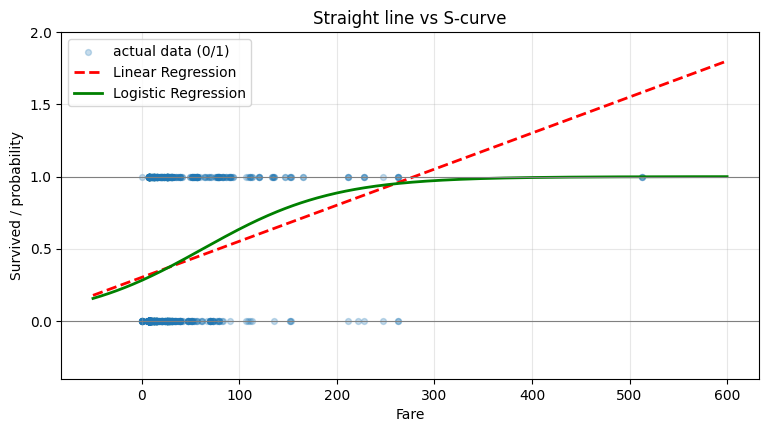

선형 회귀가 예측한 값의 범위: 0.177 ~ 1.801
  Fare=512 일 때 선형 회귀의 예측값: 1.581

로지스틱 회귀가 예측한 값의 범위: 0.156 ~ 1.000


In [71]:
from sklearn.linear_model import LinearRegression

x1 = df_org[['Fare']].values
y1 = df_org['Survived'].values

lin = LinearRegression().fit(x1, y1)
log = LogisticRegression().fit(x1, y1)

grid = np.linspace(-50, 600, 400).reshape(-1, 1)

plt.figure(figsize=(9, 4.5))
plt.scatter(x1, y1, alpha=.25, s=18, label='actual data (0/1)')
plt.plot(grid, lin.predict(grid), 'r--', lw=2, label='Linear Regression')
plt.plot(grid, log.predict_proba(grid)[:, 1], 'g', lw=2, label='Logistic Regression')
plt.axhline(1, color='gray', lw=.8); plt.axhline(0, color='gray', lw=.8)
plt.ylim(-0.4, 2.0); plt.xlabel('Fare'); plt.ylabel('Survived / probability')
plt.legend(); plt.grid(alpha=.3); plt.title('Straight line vs S-curve')
plt.show()

print("선형 회귀가 예측한 값의 범위: %.3f ~ %.3f" % (lin.predict(grid).min(), lin.predict(grid).max()))
print("  Fare=512 일 때 선형 회귀의 예측값: %.3f" % lin.predict([[512]])[0])
print()
print("로지스틱 회귀가 예측한 값의 범위: %.3f ~ %.3f"
      % (log.predict_proba(grid)[:, 1].min(), log.predict_proba(grid)[:, 1].max()))

## 3-2. 시그모이드 함수와 가중치 w, b

$$H(x)=\frac{1}{1+e^{-(wx+b)}}=\sigma(wx+b)$$

모델이 학습한다는 것은 데이터에 맞는 **w와 b를 찾는 것**입니다. 두 값이 그래프를 어떻게 바꾸는지 봅시다.

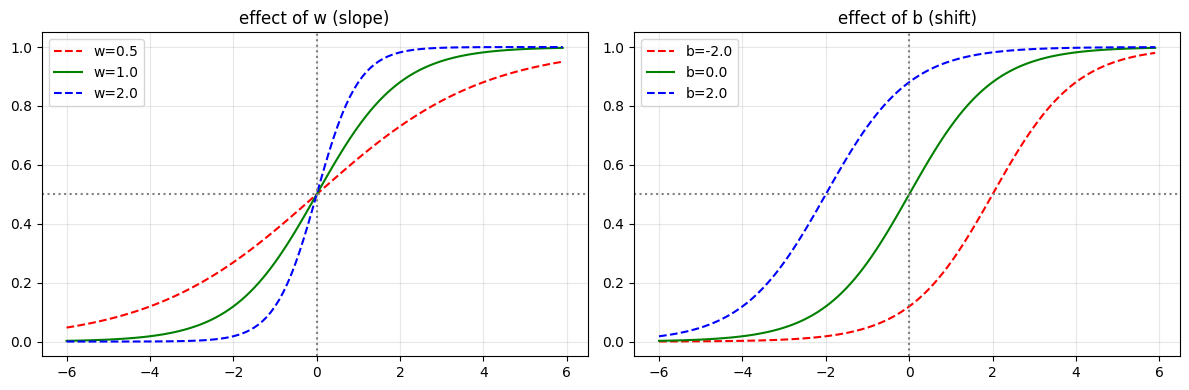

In [72]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.arange(-6.0, 6.0, 0.1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for w, style in [(0.5, 'r--'), (1.0, 'g-'), (2.0, 'b--')]:
    axes[0].plot(x, sigmoid(w * x), style, label=f'w={w}')
axes[0].set_title('effect of w (slope)')

for b, style in [(-2.0, 'r--'), (0.0, 'g-'), (2.0, 'b--')]:
    axes[1].plot(x, sigmoid(x + b), style, label=f'b={b}')
axes[1].set_title('effect of b (shift)')

for ax in axes:
    ax.axhline(0.5, color='gray', ls=':'); ax.axvline(0, color='gray', ls=':')
    ax.set_ylim(-0.05, 1.05); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

### [Q4] 직선이 아니라 S자여야 하는 이유

1. 3.1에서 **선형 회귀(빨간 점선)** 가 이진 분류에 적합하지 않은 이유를 말해주세요
2. 시그모이드는 양 끝에서 완만하고 가운데에서 급격합니다. 이 모양이 예측에서 어떤 장점을 주나요? (요금이 300인 승객과 500인 승객의 예측 확률 차이를 떠올려보세요)
3. `w`가 커지면 그래프가 어떻게 변하나요? 

**답:**

---
# 4️⃣ 의사결정나무 (Decision Tree)

## 4-1. 불순도(지니 지수)와 분할 기준

CART 알고리즘은 **지니 지수가 가장 많이 낮아지는** 분할을 고릅니다.

$$Gini = 1 - \sum_i p_i^2$$

직접 계산해서 어떤 분할이 선택될지 확인해봅시다.

In [73]:
def gini(labels):
    labels = np.asarray(labels)
    if len(labels) == 0:
        return 0.0
    p = np.array([(labels == c).mean() for c in np.unique(labels)])
    return 1 - (p ** 2).sum()

root = gini(y_train)
print("분할 전(root) 지니 지수: %.4f" % root)
print("  (훈련 데이터 %d명 = 사망 %d명 + 생존 %d명)"
      % (len(y_train), (y_train == 0).sum(), (y_train == 1).sum()))
print()

rows = []
for col, thr in [('Sex', 0.5), ('Pclass', 1.5), ('Age', 2.5), ('Embarked', 1.5)]:
    left  = y_train[X_train[col] <= thr]
    right = y_train[X_train[col] >  thr]
    weighted = (len(left) * gini(left) + len(right) * gini(right)) / len(y_train)
    rows.append({'분할 기준': f'{col} <= {thr}',
                 '왼쪽 n': len(left), '왼쪽 지니': round(gini(left), 4),
                 '오른쪽 n': len(right), '오른쪽 지니': round(gini(right), 4),
                 '가중평균 지니': round(weighted, 4),
                 '불순도 감소': round(root - weighted, 4)})

pd.DataFrame(rows).set_index('분할 기준')

분할 전(root) 지니 지수: 0.4724
  (훈련 데이터 711명 = 사망 439명 + 생존 272명)



,왼쪽 n,왼쪽 지니,오른쪽 n,오른쪽 지니,가중평균 지니,불순도 감소
분할 기준,,,,,,
Sex <= 0.5,458,0.2995,253,0.3818,0.3288,0.1436
Pclass <= 1.5,165,0.4628,546,0.4246,0.4335,0.0389
Age <= 2.5,340,0.4900,371,0.4486,0.4684,0.0040
Embarked <= 1.5,522,0.4457,189,0.4997,0.4601,0.0124


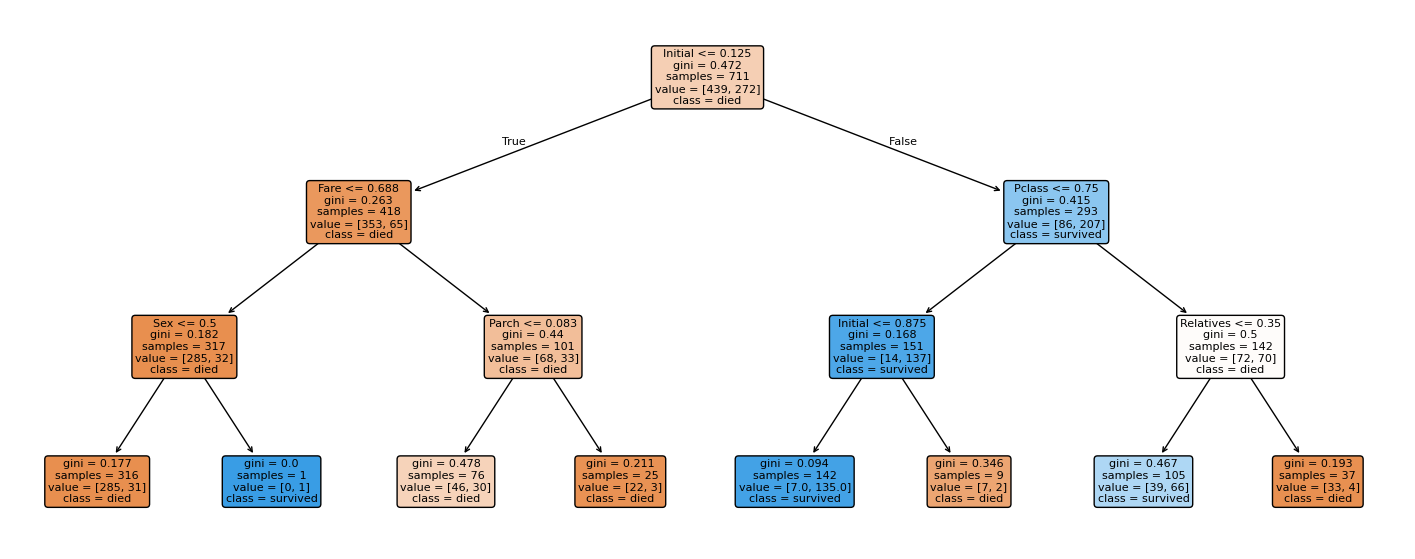

주의: 스케일링된 값으로 학습했기 때문에 그림의 임계값은 0~1로 압축된 값입니다.
depth=3 트리 | train 0.8368 | test 0.8202


In [74]:
# 실제로 트리가 고른 분할을 그림으로 확인 (깊이 3까지만)
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree3 = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train_scaled, y_train)

plt.figure(figsize=(18, 7))
plot_tree(tree3, feature_names=list(X.columns), class_names=['died', 'survived'],
          filled=True, rounded=True, fontsize=8, impurity=True)
plt.show()

print("주의: 스케일링된 값으로 학습했기 때문에 그림의 임계값은 0~1로 압축된 값입니다.")
print("depth=3 트리 | train %.4f | test %.4f"
      % (tree3.score(X_train_scaled, y_train), tree3.score(X_test_scaled, y_test)))

### [Q5] 지니 지수 읽기

1. 분할 전 지니 지수가 **0.4724**입니다. 이 값이 **0에 가까울 때**와 **0.5에 가까울 때**는 각각 어떤 상태인가요?


**답:**

## 4-2. 트리의 깊이와 과적합

max_depth  train 정확도  test 정확도  리프 개수
        1     0.7876    0.7697      2
        2     0.7904    0.7921      4
        3     0.8368    0.8202      8
        4     0.8467    0.8146     15
        5     0.8551    0.7809     25
        7     0.8861    0.7809     61
       10     0.9142    0.7472    121
     None     0.9283    0.7191    155


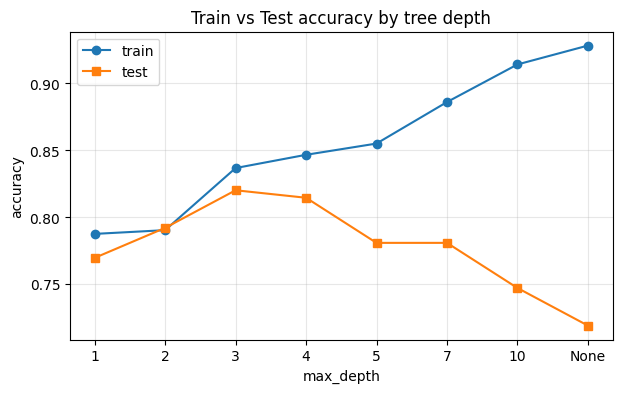

In [75]:
rows = []
for d in [1, 2, 3, 4, 5, 7, 10, None]:
    t = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train_scaled, y_train)
    rows.append({'max_depth': str(d),
                 'train 정확도': round(t.score(X_train_scaled, y_train), 4),
                 'test 정확도':  round(t.score(X_test_scaled,  y_test),  4),
                 '리프 개수': t.get_n_leaves()})

depth_df = pd.DataFrame(rows)
print(depth_df.to_string(index=False))

plt.figure(figsize=(7, 4))
plt.plot(range(len(depth_df)), depth_df['train 정확도'], 'o-', label='train')
plt.plot(range(len(depth_df)), depth_df['test 정확도'],  's-', label='test')
plt.xticks(range(len(depth_df)), depth_df['max_depth'])
plt.xlabel('max_depth'); plt.ylabel('accuracy')
plt.legend(); plt.grid(alpha=.3); plt.title('Train vs Test accuracy by tree depth')
plt.show()

In [76]:
# 가지치기(pruning): ccp_alpha를 키우면 도움이 안 되는 가지를 잘라냅니다.
rows = []
for a in [0.0, 0.001, 0.003, 0.005, 0.01, 0.02]:
    t = DecisionTreeClassifier(random_state=42, ccp_alpha=a).fit(X_train_scaled, y_train)
    rows.append({'ccp_alpha': a,
                 'train 정확도': round(t.score(X_train_scaled, y_train), 4),
                 'test 정확도':  round(t.score(X_test_scaled,  y_test),  4),
                 '리프 개수': t.get_n_leaves(), '깊이': t.get_depth()})

pd.DataFrame(rows).set_index('ccp_alpha')

,train 정확도,test 정확도,리프 개수,깊이
ccp_alpha,,,,
0.000,0.9283,0.7191,155,15
0.001,0.9086,0.7753,57,13
0.003,0.8650,0.7921,15,7
0.005,0.8354,0.8202,6,3
0.010,0.8354,0.8202,6,3
0.020,0.8284,0.8146,4,3


### [Q6] 깊이, 과적합, 가지치기

1. `max_depth`가 깊어질수록 train 정확도와 test 정확도는 각각 어떻게 변하나요? 
2. 두 선의 간격이 벌어지는 현상을 뭐라고 부르나요? 

**답:**

---
# 5️⃣ SVM (Support Vector Machine)

## 5-1. 마진과 서포트 벡터

SVM은 **가장 넓은 마진**을 가진 결정 경계를 찾습니다.
개념이 잘 보이도록 2차원 가상 데이터로 먼저 확인합니다.
- 실선 = 결정 경계, 점선 = 마진 경계
- 초록 동그라미 = **서포트 벡터** (마진 위/안쪽에 있는 데이터)

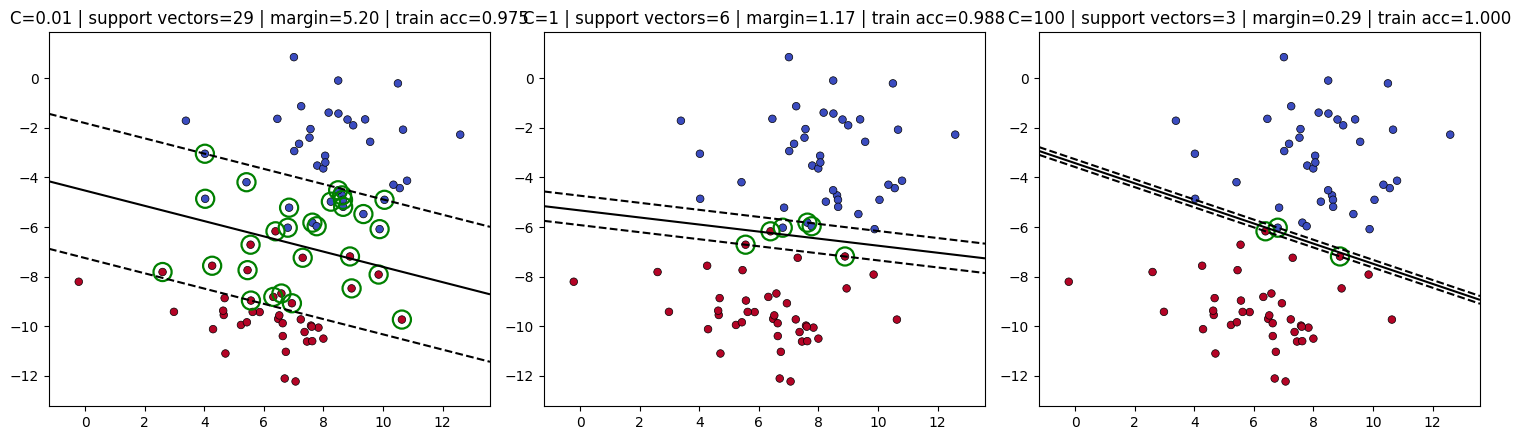

In [77]:
from sklearn.datasets import make_blobs

Xb, yb = make_blobs(n_samples=80, centers=2, cluster_std=1.8, random_state=6)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, Cval in zip(axes, [0.01, 1, 100]):
    m = SVC(kernel='linear', C=Cval).fit(Xb, yb)

    ax.scatter(Xb[:, 0], Xb[:, 1], c=yb, cmap='coolwarm', s=30, edgecolors='k', linewidths=.5)
    xx = np.linspace(Xb[:, 0].min() - 1, Xb[:, 0].max() + 1, 60)
    yy = np.linspace(Xb[:, 1].min() - 1, Xb[:, 1].max() + 1, 60)
    YY, XX = np.meshgrid(yy, xx)
    Z = m.decision_function(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)
    ax.contour(XX, YY, Z, levels=[-1, 0, 1], colors='k', linestyles=['--', '-', '--'])
    ax.scatter(m.support_vectors_[:, 0], m.support_vectors_[:, 1],
               s=170, facecolors='none', edgecolors='green', linewidths=1.6)

    margin = 2 / np.linalg.norm(m.coef_[0])
    ax.set_title(f'C={Cval} | support vectors={len(m.support_vectors_)} | '
                 f'margin={margin:.2f} | train acc={m.score(Xb, yb):.3f}')
plt.tight_layout(); plt.show()

## 5-2. 커널 — 직선으로 나눌 수 없을 때

선형 커널은 직선(초평면)만 그을 수 있습니다. `rbf` 커널은 데이터를 더 높은 차원으로 보내 곡선 경계를 만듭니다.

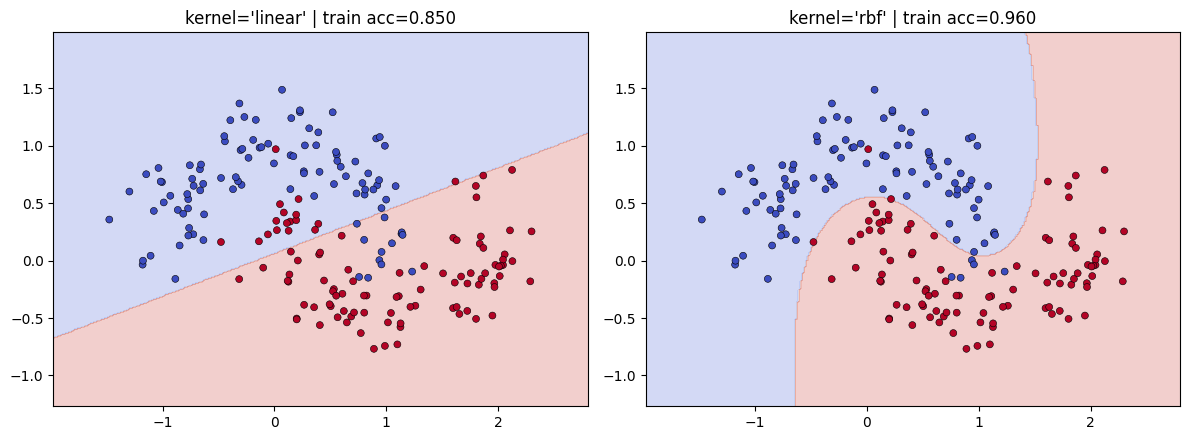

In [78]:
from sklearn.datasets import make_moons

Xm, ym = make_moons(n_samples=200, noise=0.2, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, kern in zip(axes, ['linear', 'rbf']):
    m = SVC(kernel=kern, C=1).fit(Xm, ym)
    xx, yy = np.meshgrid(np.linspace(Xm[:, 0].min() - .5, Xm[:, 0].max() + .5, 300),
                         np.linspace(Xm[:, 1].min() - .5, Xm[:, 1].max() + .5, 300))
    Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=.25, cmap='coolwarm')
    ax.scatter(Xm[:, 0], Xm[:, 1], c=ym, cmap='coolwarm', s=25, edgecolors='k', linewidths=.4)
    ax.set_title(f"kernel='{kern}' | train acc={m.score(Xm, ym):.3f}")
plt.tight_layout(); plt.show()

## 5-3. 타이타닉 데이터에 적용

In [79]:
rows = []
for kern in ['linear', 'rbf']:
    for Cval in [0.01, 0.1, 1, 10, 100]:
        m = SVC(kernel=kern, C=Cval, random_state=42).fit(X_train_scaled, y_train)
        rows.append({'kernel': kern, 'C': Cval,
                     'train 정확도': round(m.score(X_train_scaled, y_train), 4),
                     'test 정확도':  round(m.score(X_test_scaled,  y_test),  4),
                     '서포트 벡터 수': int(m.n_support_.sum())})

svm_df = pd.DataFrame(rows)
print(svm_df.to_string(index=False))
print()
print("훈련 데이터 수:", len(X_train), "명")
print()
print("[ 스케일링의 영향 (rbf, C=1) ]")
print("스케일링 X: %.4f" % SVC(random_state=42).fit(X_train, y_train).score(X_test, y_test))
print("스케일링 O: %.4f" % SVC(random_state=42).fit(X_train_scaled, y_train).score(X_test_scaled, y_test))

kernel      C  train 정확도  test 정확도  서포트 벡터 수
linear   0.01     0.7904    0.7697       543
linear   0.10     0.7904    0.7697       340
linear   1.00     0.7932    0.7753       306
linear  10.00     0.7862    0.7809       307
linear 100.00     0.7862    0.7809       305
   rbf   0.01     0.7145    0.7303       547
   rbf   0.10     0.8129    0.7978       382
   rbf   1.00     0.8425    0.8146       307
   rbf  10.00     0.8579    0.8202       297
   rbf 100.00     0.8776    0.7865       289

훈련 데이터 수: 711 명

[ 스케일링의 영향 (rbf, C=1) ]
스케일링 X: 0.8034
스케일링 O: 0.8146


### [Q7] 마진, C, 커널

1. `C`는 "마진을 넓게 유지하는 것"과 "훈련 데이터를 틀리지 않는 것" 중 어느 쪽에 무게를 두는지 정하는 값입니다. `C`가 클 때와 작을 때 각각 어떤 위험이 있는지 과적합/과소적합과 연결해 설명해주세요.

**답:**

---
# 2️ 분류 모델 — (4) kNN (K-Nearest Neighbor)

kNN은 **학습이 없습니다.** 새 데이터가 들어오면 그때 훈련 데이터와의 거리를 재서,
가장 가까운 k명의 정답을 다수결로 따릅니다. 그래서 `k`가 사실상 유일한 손잡이입니다.

In [80]:
from sklearn.neighbors import KNeighborsClassifier

rows = []
for k in [1, 3, 5, 9, 15, 25, 51]:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train_scaled, y_train)
    rows.append({'k': k,
                 'train 정확도': round(knn.score(X_train_scaled, y_train), 4),
                 'test 정확도':  round(knn.score(X_test_scaled,  y_test),  4)})

pd.DataFrame(rows).set_index('k')

,train 정확도,test 정확도
k,,
1,0.8833,0.7247
3,0.8720,0.7528
5,0.8537,0.7697
9,0.8650,0.7921
15,0.8312,0.8034
25,0.8256,0.7978
51,0.8003,0.7865


### [Q8] k는 무엇을 조절하는가

1. `k=1`일 때 train 정확도(0.8833)가 test 정확도(0.7247)보다 훨씬 높습니다.
   - 먼저 **`k=1` 모델이 예측하는 방식**을 한 문장으로 적어주세요. (새 승객이 들어오면 훈련 데이터 중 몇 명을 보고, 그 사람의 정답을 어떻게 쓰나요?)
   - 그 동작을 근거로, **훈련 데이터를 예측할 때 유독 점수가 높은 이유**를 설명해주세요.
2. `k`를 키우면 train과 test 정확도는 각각 어떻게 변하나요? 표에서 숫자를 읽어 적고, 이유를 설명해주세요.


**답:**

In [81]:
# 보조 자료 ① ─ k를 극단적으로 키우면?
for k in [51, 301, 711]:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train_scaled, y_train)
    pred = knn.predict(X_test_scaled)
    print(f"  k={k:3d} | train {knn.score(X_train_scaled, y_train):.4f}"
          f" | test {knn.score(X_test_scaled, y_test):.4f}"
          f" | 예측에 등장하는 값: {np.unique(pred)}")
print(f"  기준선(무조건 사망으로 찍기) test 정확도: {(y_test == 0).mean():.4f}")
print(f"  훈련 데이터 수: {len(X_train)}명")
print()

# 보조 자료 ② ─ 구간화 때문에 좌표가 겹치는 훈련 데이터
tr = X_train.copy()
tr['y'] = y_train.values
g = tr.groupby(list(X_train.columns), observed=True)['y'].agg(['count', 'nunique'])
conflict = g[(g['count'] > 1) & (g['nunique'] > 1)]
print(f"  훈련 데이터 {len(X_train)}명의 서로 다른 좌표 조합: {len(g)}개")
print(f"  다른 승객과 좌표가 완전히 겹치는 인원: {int(tr.drop(columns='y').duplicated(keep=False).sum())}명")
print(f"  그중 생사가 엇갈리는 좌표: {len(conflict)}개 조합, {int(conflict['count'].sum())}명")
knn1 = KNeighborsClassifier(n_neighbors=1).fit(X_train_scaled, y_train)
print(f"  → k=1의 train 오답: {int((knn1.predict(X_train_scaled) != y_train.values).sum())}명"
      f" (train 정확도 {knn1.score(X_train_scaled, y_train):.4f})")

  k= 51 | train 0.8003 | test 0.7865 | 예측에 등장하는 값: [0 1]
  k=301 | train 0.7707 | test 0.7697 | 예측에 등장하는 값: [0 1]
  k=711 | train 0.6174 | test 0.6180 | 예측에 등장하는 값: [0]
  기준선(무조건 사망으로 찍기) test 정확도: 0.6180
  훈련 데이터 수: 711명

  훈련 데이터 711명의 서로 다른 좌표 조합: 367개
  다른 승객과 좌표가 완전히 겹치는 인원: 457명
  그중 생사가 엇갈리는 좌표: 38개 조합, 218명
  → k=1의 train 오답: 83명 (train 정확도 0.8833)


### [Q9] 극단의 k와, k=1이 만점을 못 받은 이유

1. `k=711`(= 훈련 데이터 전체)일 때 예측에 등장하는 값은 `[0]` 하나뿐이고, 정확도는 기준선과 정확히 같습니다. 왜 이렇게 되는지 kNN의 다수결 방식으로 설명해주세요. 이건 과적합인가요, 과소적합인가요?
2. `k=1`이면 훈련 데이터를 100% 맞혀야 할 것 같은데 실제로는 0.8833입니다. 왜 그럴까요?


**답:**